In [46]:
# Import the FEMSystem Class from directory above
import sys
from VisualizeVF import VisualizeVF
sys.path.append('..')
from FEMSystem import FEMSystem

import jax.numpy as jnp
import pickle
import matplotlib.pyplot as plt
import numpy as np

# Step 0: Load in File, Statics Solution

In [2]:
# First load in 2D mesh and 2D modes (statics solution)
pickled_obj = {}

with open('./../2D/allplots/square10sep20num100/results.pkl', 'rb') as f:
    pickled_obj= pickle.load(f)

femsystem:FEMSystem = pickled_obj["femsystem"]
femsystem.saveFigsDir = None # Turn OFF saving plots
u_even,u_odd = pickled_obj["u_even"],pickled_obj["u_odd"]
u_left,u_right = 1/jnp.sqrt(2)*(u_even - u_odd), 1/jnp.sqrt(2)* (u_even + u_odd)
u_even_interior,u_odd_interior = u_even[femsystem.interior_dofs],u_odd[femsystem.interior_dofs]
theta_at_dofs = pickled_obj["theta_at_dofs"]
n,N,coeffs = pickled_obj["n"],pickled_obj["parameters"]["N"],pickled_obj["coeffs"]
E_J,E_C = pickled_obj["E_J"],pickled_obj["E_C"]

# Get the mesh
mesh = femsystem.mesh

# Print number of degrees of freedom
print(f"Number of degrees of freedom: {femsystem.dofs}")

# Print number of elements
print(f"Number of elements: {femsystem.elements}")
print(len(coeffs))

Number of degrees of freedom: 3881
Number of elements: 1914
50


# Step 2: Helmholtz Solver, find $A$

Solving: 

$\nabla \times \nabla \times A + (a + b \langle \Psi^\dagger \Psi \rangle) A = j$

Where

$a = - \frac{\omega_d^2}{\bar{c}^2}$

$b = \frac{1}{\kappa^2}\frac{\overline{Area}}{N}$

a_coeff, b_coeff: -5.925976992996065e-38 4.905462585235248e-05


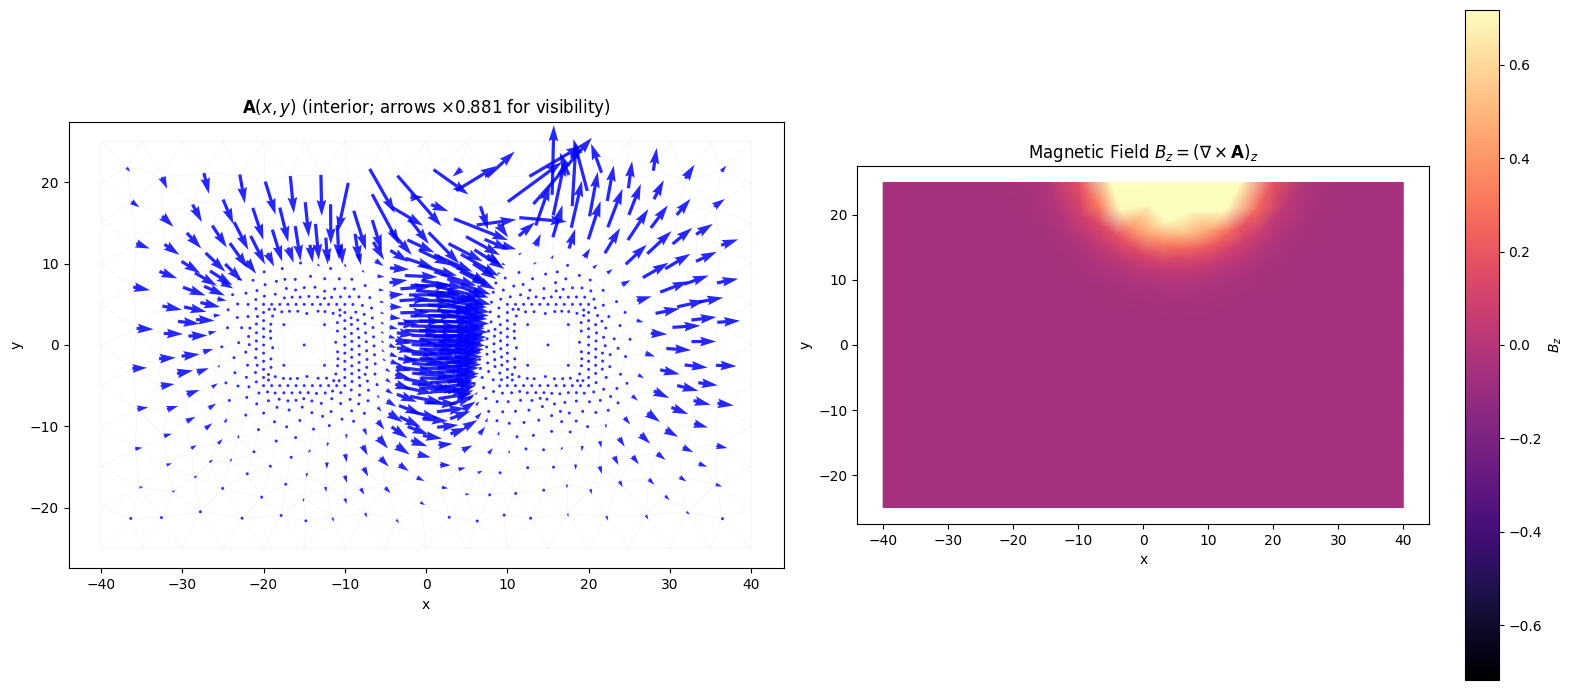

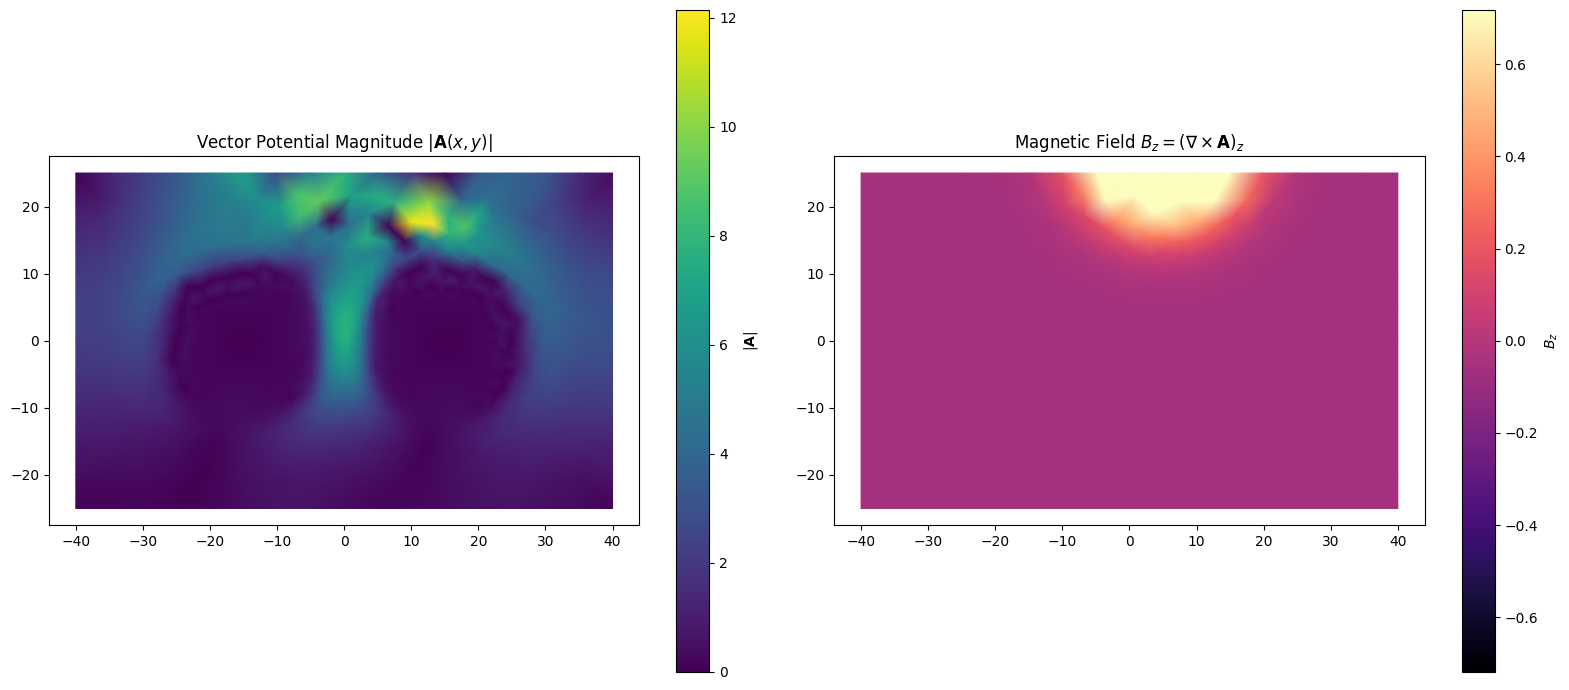

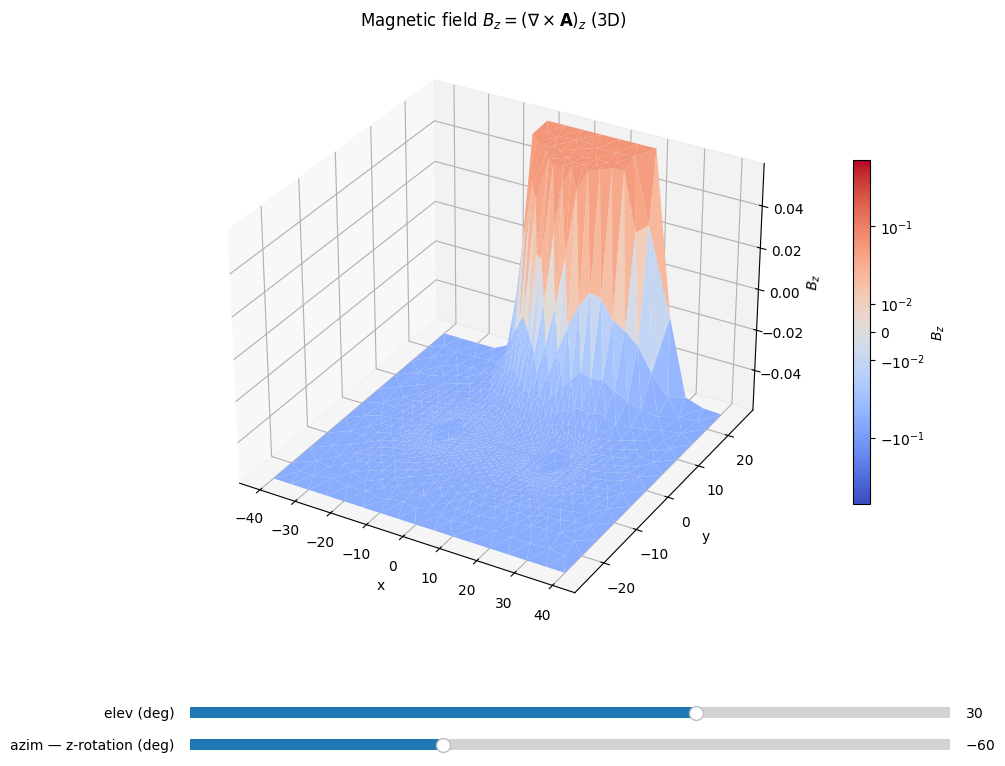

(<Figure size 1000x800 with 4 Axes>,
 <Axes3D: title={'center': 'Magnetic field $B_z = (\\nabla \\times \\mathbf{A})_z$ (3D)'}, xlabel='x', ylabel='y', zlabel='$B_z$'>)

In [48]:
from scipy.sparse.linalg import spsolve
from skfem import MeshTri, ElementTriN1, ElementTriN2, ElementTriP1, ElementTriP2, Basis, BilinearForm, LinearForm, asm, condense
from skfem.helpers import curl, dot

omega_d = 1.87
c_bar = 7.681775769968403e18
kappa = 403.8359796590388
area = 800
N_area = 100  # only for b_coeff; do not confuse with pickled particle count

a_coeff = - (omega_d/c_bar)**2
b_coeff = 1/(kappa**2) * area / N_area
print("a_coeff, b_coeff:", a_coeff, b_coeff)

source_coord = (5.0, 30.0)
sigma = 10.0
m = 1000 # Magnitude of drive. 

########################################################
# Solver Below
########################################################

nodal_element = femsystem.element  # Get the scikit-fem element used for nodal basis (e.g., ElementTriP1/P2)
nedelic_element = ElementTriN1()
# Same intorder as pickled FEMSystem (often 5 in 2DTwoModesOpt). Otherwise asm(...) rejects
# femsystem.basis.interpolate(psi_exp): quadrature must match basis_edge.
basis_nodal = Basis(mesh, nodal_element, intorder=femsystem.intorder)
basis_edge = Basis(mesh, nedelic_element, intorder=femsystem.intorder)

nodes_x = mesh.p[0]
nodes_y = mesh.p[1]
epsilon = 1e-4
psi_exp = (u_left **2 + u_right**2) * N / 2 + epsilon
# Interpolate psi_exp with femsystem.basis: same FE space as u_* (often P2) and same quadrature
# as basis_edge via intorder above. Using basis_nodal.interpolate(psi_exp) fails (wrong N or wrong quads).

# Strip current on the left (like the working "Initial Test" cell), not a point delta — fills the domain with B.
# On MeshTri2, mesh.p includes midside nodes; P1 nodal DOFs are basis_nodal.N == mesh.nvertices in the *vertex* sense.

@BilinearForm
def bilinear_form(u,v,w):
    # / N_area keeps London term O(1) with psi_exp (same balance as your earlier working runs)
    second_term_coeff = a_coeff + b_coeff * w['psi_exp'] / N_area * 100
    return curl(u) * curl(v) + second_term_coeff * dot(u, v)

@LinearForm
def general_source(v, w):
    b_vec = np.array([w['bx'], w['by']])
    return dot(b_vec, v)

@LinearForm
def dipole_source(v, w):
    x = w.x[0]
    y = w.x[1]
    x0, y0 = source_coord
    M = (m / (np.pi * sigma**2)) * np.exp(-((x - x0)**2 + (y - y0)**2) / sigma**2)
    Jx = -M * 2 * (y - y0) / sigma**2
    Jy =  M * 2 * (x - x0) / sigma**2
    J_vec = np.array([Jx, Jy])
    return dot(J_vec, v)

A_matrix = asm(bilinear_form, basis_edge,
               psi_exp=femsystem.basis.interpolate(np.asarray(psi_exp, dtype=np.float64)))


b_vector = asm(dipole_source, basis_edge)


# Delta function Source, comment this out for Gaussian Source
# Search closest dof in basis_nodal.doflocs and size b_* with basis_nodal.N so interpolate() agrees.
# source_coord = (0.0, 30.0)
# source_coord_arr = np.array(source_coord).reshape(2, 1)
# dof_xy = basis_nodal.doflocs
# closest_node_index = int(np.argmin(np.sum((dof_xy - source_coord_arr) ** 2, axis=0)))
# b_nodal_values = np.zeros((2, basis_nodal.N))
# b_nodal_values[1, closest_node_index] = 1.0
# b_vector = asm(general_source, basis_edge,
#                bx=basis_nodal.interpolate(b_nodal_values[0,:]),
#                by=basis_nodal.interpolate(b_nodal_values[1,:]))

A_sol = np.zeros(basis_edge.N)
D = basis_edge.get_dofs().all()
A_int, b_int, x_int, I = condense(A_matrix, b_vector, D=D)
A_sol[I] = spsolve(A_int, b_int)

vis = VisualizeVF(mesh, basis_edge, A_sol)
fig, ax = vis.visualize_vf(A_sol, bz_symmetric_percentile=99.0)
vis.visualize_vf_mag(A_sol, bz_symmetric_percentile=99.0)

vis.visualize_bz_surface(A_sol, bz_symmetric_percentile=99.0)

# Step 2: Rabi Oscillations

## Step 2.1: Compute the integrals and find the corrections

In [ ]:
from __future__ import annotations

import numpy as np
import jax.numpy as jnp
from scipy.sparse.linalg import spsolve
from skfem import Basis, BilinearForm, ElementTriP1, ElementVector, LinearForm, asm
from skfem.helpers import div, dot
from jax.scipy.sparse.linalg import cg


def _two_by_two(integrand, fs, u_left, u_right):
    """Fill [[LL, LR], [RL, RR]] using femsystem.integrate_two."""
    e_ll = fs.integrate_two(integrand, u_left, u_left)
    e_lr = fs.integrate_two(integrand, u_left, u_right)
    e_rl = fs.integrate_two(integrand, u_right, u_left)
    e_rr = fs.integrate_two(integrand, u_right, u_right)
    return jnp.array([[e_ll, e_lr], [e_rl, e_rr]])

def _project_nedelec_to_vector_p1(femsystem, basis_edge, A_sol: np.ndarray):
    """L² project Nédélec A onto vector P1 (same mesh and quadrature order as modes)."""
    mesh = basis_edge.mesh
    basis_vec_p1 = Basis(
        mesh, ElementVector(ElementTriP1()), intorder=femsystem.intorder
    )

    @BilinearForm
    def mass_vec(u, v, w):
        return dot(u, v)

    @LinearForm
    def rhs_proj(v, w):
        return dot(w["A"], v)

    A_disc = basis_edge.interpolate(np.asarray(A_sol, dtype=np.float64))
    M = asm(mass_vec, basis_vec_p1)
    rhs = asm(rhs_proj, basis_vec_p1, A=A_disc)
    coeffs = spsolve(M, rhs)
    A_p1_disc = basis_vec_p1.interpolate(coeffs)
    val = np.asarray(A_p1_disc.value)
    Ax = jnp.asarray(val[0])
    Ay = jnp.asarray(val[1])
    divA = jnp.asarray(div(A_p1_disc))
    a2 = Ax * Ax + Ay * Ay
    return Ax, Ay, divA, a2

def epsilon_four_terms(
    femsystem,
    basis_edge,
    A_sol,
    phi_i,
    phi_j,
):

    def T_nabla2(u1, g1, u2, g2, x):

        del u1, u2, x
        return -jnp.sum(jnp.conj(g1) * g2, axis=0)

    Ax, Ay, divA, a2 = _project_nedelec_to_vector_p1(femsystem, basis_edge, A_sol)

    def T_divA(u1, g1, u2, g2, x):
        del g1, g2, x
        return 1j*jnp.conj(u1) * divA * u2

    def T_Adot_grad(u1, g1, u2, g2, x):
        del g1, x
        adot = Ax * g2[0] + Ay * g2[1]
        return 1j*jnp.conj(u1) * adot

    def T_A2(u1, g1, u2, g2, x):
        del g1, g2, x
        return jnp.conj(u1) * a2 * u2

    laplacian_term = femsystem.integrate_two(T_nabla2, phi_i, phi_j)
    first_cross_term = femsystem.integrate_two(T_divA, phi_i, phi_j)
    second_cross_term = femsystem.integrate_two(T_Adot_grad, phi_i, phi_j)
    a2_term = femsystem.integrate_two(T_A2, phi_i, phi_j)

    return laplacian_term, first_cross_term, second_cross_term, a2_term

# Without a factor of 4 in front, simply four terms of \int \phi_i^* (i\grad + A)^2 \phi_j dx
epsilon_four_terms(femsystem, basis_edge, A_sol, u_left, u_left)

# Get phi_theta_int, or the green's function times charge background
A_int, P_int = femsystem.get_stiffness_matrix()
theta_at_quad = femsystem._interpolate_values(theta_at_dofs)
weighted_theta = theta_at_quad * femsystem.weights
v_theta = P_int.T @ weighted_theta.ravel()
phi_theta_int, _ = cg(A_int, v_theta)


# Returns a function of time
# Note: epsilon_ij must be built from the (u1, u2) pair passed in, not globals.
def get_epsilon_func(femsystem, basis_edge, A_sol, u1, u2, phi_theta_int, omega_d):
    laplacian_term, first_cross_term, second_cross_term, a2_term = epsilon_four_terms(
        femsystem, basis_edge, A_sol, u1, u2
    )

    # Compute the external-potential overlap <u1|V_ext|u2>
    u_quad1 = femsystem._interpolate_values(u1)
    u_quad2 = femsystem._interpolate_values(u2)
    weighted_u2 = (jnp.conj(u_quad1) * u_quad2) * femsystem.weights
    v_u2 = P_int.T @ weighted_u2.ravel()
    potential = -2 * (v_u2 @ phi_theta_int)

    def epsilon_func(t):
        s = jnp.sin(omega_d * t)
        return 4 * (laplacian_term + first_cross_term * s + second_cross_term * s + a2_term * jnp.sin(2 * omega_d * t)) + potential

    return epsilon_func

def get_corrections(femsystem,basis_edge,A_sol,u1,u2,omega_d):
    laplacian_term, first_cross_term, second_cross_term, a2_term = epsilon_four_terms(
        femsystem, basis_edge, A_sol, u1, u2
    )

    def correction_func(t):
        s = jnp.sin(omega_d * t)
        res = 1j*first_cross_term * s + 1j*second_cross_term * s + a2_term * jnp.sin(2 * omega_d * t)
        return res

    return correction_func


def compute_U(u1, u2, u3, u4, area, N):
    # U_ijkl for b_i^\dagger b_j^\dagger b_k b_l uses conjugates on bra modes.
    left_func = jnp.conj(u1) * jnp.conj(u2)
    right_func = u3 * u4
    return area / N * femsystem.double_integral_cg(
        lambda u1, a, u2, c, d: u1,
        lambda u1, b, u2, c, d: u2,
        A_int,
        P_int,
        left_func,
        right_func,
    )

# get_epsilon_func(femsystem, basis_edge, A_sol, u_left, u_right,phi_theta_int,omega_d)
get_corrections(femsystem,basis_edge,A_sol,u_left,u_right,omega_d)

<function __main__.get_corrections.<locals>.correction_func(t)>

In [40]:
import jax.numpy as jnp

import jax.numpy as jnp

def charge_imbalance_eigenvalues(n, N):
    # m = (N_R - N_L)/2 (your convention: +1/2 means one extra on right)
    if n % 2 == 0:
        m_values = jnp.arange(-n//2, n//2) + 0.5   # half-integers
    else:
        m_values = jnp.arange(-(n//2), n//2 + 1)   # integers
    n_left_values  = (N / 2) - m_values
    n_right_values = (N / 2) + m_values
    return m_values, n_left_values, n_right_values

def left_lowering_operator(n, N):
    # b_L |m> = sqrt(N_L(m)) |m + 1/2>  -> in this indexed basis: i -> i+1
    _, n_left_values, _ = charge_imbalance_eigenvalues(n, N)
    mat = jnp.zeros((n, n))
    for i in range(0, n - 1):
        mat = mat.at[i + 1, i].set(jnp.sqrt(n_left_values[i]))
    return mat

def left_raising_operator(n, N):
    return left_lowering_operator(n, N).T

def right_lowering_operator(n, N):
    # b_R |m> = sqrt(N_R(m)) |m - 1/2>  -> in this indexed basis: i -> i-1
    _, _, n_right_values = charge_imbalance_eigenvalues(n, N)
    mat = jnp.zeros((n, n))
    for i in range(1, n):
        mat = mat.at[i - 1, i].set(jnp.sqrt(n_right_values[i]))
    return mat

def right_raising_operator(n, N):
    return right_lowering_operator(n, N).T

def total_left_operator(n, N):
    """
    Returns the total left operator matrix (n x n diagonal) for left particle number in the middle n states.
    """
    m_values, n_left_values, n_right_values = charge_imbalance_eigenvalues(n, N)
    return jnp.diag(n_left_values)

def total_right_operator(n, N):
    """
    Returns the total right operator matrix (n x n diagonal) for right particle number in the middle n states.
    """
    m_values, n_left_values, n_right_values = charge_imbalance_eigenvalues(n, N)
    return jnp.diag(n_right_values)

n,N = 50,100
# print(right_raising_operator(n,N)@right_lowering_operator(n,N)-total_right_operator(n,N))
# print(left_raising_operator(n,N)@left_lowering_operator(n,N)-total_left_operator(n,N))

## Step 2.2: Add Corrections to Charge Qubit Hamiltonian

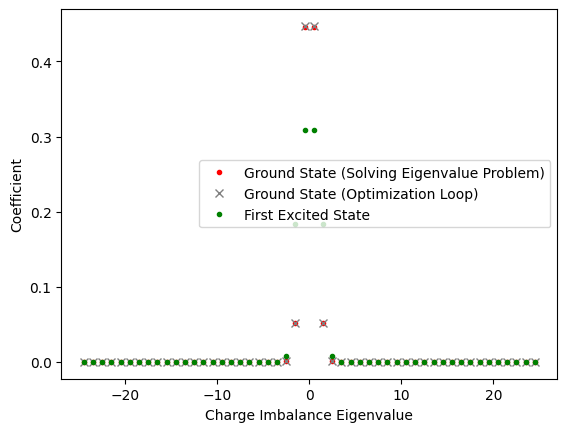

Qubit Frequency: 1.8735647201538086


In [41]:
# Create the Hamiltonian Operator over Truncated Basis, to find eigenvectors for first excited state
def reduced_hamiltonian(n,E_J,E_C,plot=False,coeffs=None):
    # Copy these three matrix construction functions from 3DTwoModesOpt.py
    x = (n-1)/2 - jnp.arange(n) # Charge Imbalance Eigenvalue, centered at 0 

    def Jz2(n):
        j = (n-1)/2
        diagonals = j - jnp.arange(n)
        return jnp.diag(diagonals**2)

    def off_diag(n,k):
        ones_super, ones_sub = jnp.ones(n - k, dtype=jnp.int32),jnp.ones(n - k, dtype=jnp.int32)
        super_diag_matrix,sub_diag_matrix= jnp.diag(ones_super, k=k),jnp.diag(ones_sub, k=-1*k)
        result = super_diag_matrix + sub_diag_matrix
        return result 

    def cos_phi(n):
        return off_diag(n,1) / 2

    hamiltonian = E_C * Jz2(n) - E_J * cos_phi(n) # No need for e_0 term, since we are only interested in eigenvectors

    # Find Eigenvalues and Eigenvectors
    eigenvalues,eigenvectors = jnp.linalg.eigh(hamiltonian)

    # Plot the ground state, first eigenvector
    # Normalize every eigenstate column vector
    eigenvectors = eigenvectors / jnp.sqrt(jnp.sum(jnp.abs(eigenvectors)**2, axis=0, keepdims=True))
    ground_state_coeffs = eigenvectors[:,0] / jnp.sqrt(jnp.sum(eigenvectors[:,0]**2))
    first_excited_coeffs = eigenvectors[:,1] / jnp.sqrt(jnp.sum(eigenvectors[:,1]**2))

    if plot: 
        ground_state_coeffs_from_optimization = coeffs / jnp.sqrt(jnp.sum(coeffs**2))
        plt.plot(x,ground_state_coeffs**2,".",color="red",label="Ground State (Solving Eigenvalue Problem)")
        plt.plot(x,ground_state_coeffs_from_optimization**2,"x",color="grey",label="Ground State (Optimization Loop)")
        plt.plot(x,first_excited_coeffs**2,".",color="green",label="First Excited State")
        plt.xlabel("Charge Imbalance Eigenvalue")
        plt.ylabel("Coefficient")
        plt.legend()
        plt.show()
    
    # Get the frequency of the qubit
    sorted_eigenvalues = jnp.sort(eigenvalues)
    omega_q = sorted_eigenvalues[1] - sorted_eigenvalues[0]

    return hamiltonian, omega_q, eigenvectors, eigenvalues # x is the charge imbalance eigenvalue

h_m,E_q,eigenvectors,eigenvalues = reduced_hamiltonian(n,E_J,E_C,plot=True,coeffs=coeffs)

def H_discrete(h_m,femsystem,basis_edge,A_sol,u_left,u_right,omega_d):

    # Compute the total time evolution matrix:
    left_raising = left_raising_operator(n,N)
    left_lowering = left_lowering_operator(n,N)
    right_raising = right_raising_operator(n,N)
    right_lowering = right_lowering_operator(n,N)

    raisings = [left_raising,right_raising] # Daggers
    lowerings = [left_lowering,right_lowering] # Regular b operators

    modes = [u_left,u_right]

    # Precompute epsilon functions for all (i, j) and store in a 2x2 array
    epsilon_funcs = [[get_corrections(femsystem, basis_edge, A_sol, modes[i], modes[j], omega_d) for j in range(2)] for i in range(2)]
    # Precompute raising@lowering matrices for all (i, j)
    raising_lowering_mats = [[raisings[i] @ lowerings[j] for j in range(2)] for i in range(2)]

    def res(t):
        mat = h_m

        # Corrections
        for i in range(2):
            for j in range(2):
                epsilon_val = epsilon_funcs[i][j](t)
                curr_mat = raising_lowering_mats[i][j]
                mat += epsilon_val * curr_mat
        mat = 0.5 * (mat + jnp.conj(mat.T))
        return mat
    
    return res

H = H_discrete(h_m,femsystem,basis_edge,A_sol,u_left,u_right,omega_d)
print(f"Qubit Frequency: {E_q}")

In [42]:
# Now Compute the total time evolution matrix:

def compute_mat(femsystem,basis_edge,A_sol,u_left,u_right,phi_theta_int,omega_d,N,n):
    # Compute the total time evolution matrix:
    left_raising = left_raising_operator(n,N)
    left_lowering = left_lowering_operator(n,N)
    right_raising = right_raising_operator(n,N)
    right_lowering = right_lowering_operator(n,N)

    raisings = [left_raising,right_raising] # Daggers
    lowerings = [left_lowering,right_lowering] # Regular b operators

    modes = [u_left,u_right]

    # Precompute epsilon functions for all (i, j) and store in a 2x2 array
    epsilon_funcs = [[get_epsilon_func(femsystem, basis_edge, A_sol, modes[i], modes[j], phi_theta_int, omega_d) for j in range(2)] for i in range(2)]

    # Precompute raising@lowering matrices for all (i, j)
    raising_lowering_mats = [[raisings[i] @ lowerings[j] for j in range(2)] for i in range(2)]

    # Precompute U_ijkl values for all (i, j, k, l) and store in a 2x2x2x2 array
    U_vals = [[[[compute_U(modes[i], modes[j], modes[k], modes[l], area, N)
                for l in range(2)] for k in range(2)]
                for j in range(2)] for i in range(2)]

    # Precompute raising@raising@lowering@lowering matrices for all (i, j, k, l)
    raising2_lowering2_mats = [[[[raisings[i] @ raisings[j] @ lowerings[k] @ lowerings[l]
                                 for l in range(2)] for k in range(2)]
                                 for j in range(2)] for i in range(2)]
    

    def res(t):
        mat = jnp.zeros((n, n), dtype=jnp.complex128)

        # Epsilons
        for i in range(2):
            for j in range(2):
                epsilon_val = epsilon_funcs[i][j](t)
                curr_mat = raising_lowering_mats[i][j]
                mat += epsilon_val * curr_mat

        # U_ijkls
        for i in range(2):
            for j in range(2):
                for k in range(2):
                    for l in range(2):
                        U_val = U_vals[i][j][k][l]
                        curr_mat = raising2_lowering2_mats[i][j][k][l]
                        mat += U_val * curr_mat

        # Enforce Hermiticity numerically (and absorb tiny quadrature asymmetries).
        mat = 0.5 * (mat + jnp.conj(mat.T))
        return mat


    # epsilons = [get_epsilon_func(femsystem,basis_edge,A_sol,u1,u2,phi_theta_int,omega_d) for u1 in modes for u2 in modes]

    # def res(t):
    #     mat = jnp.diag(jnp.zeros(n))

    #     # Epsilons
    #     for i in range(2):
    #         for j in range(2):
    #             u1,u2 = modes[i],modes[j]
    #             epsilon_func = get_epsilon_func(femsystem,basis_edge,A_sol,u1,u2,phi_theta_int,omega_d)
    #             mat += epsilon_func(t) * raisings[i]@lowerings[j]
        
    #     # U_ijkls
    #     for i in range(2):
    #         for j in range(2):
    #             for k in range(2):
    #                 for l in range(2):
    #                         mat += compute_U(modes[i],modes[j],modes[k],modes[l],area,N) * raisings[i]@raisings[j]@lowerings[k]@lowerings[l]
    #     return mat

    return res    
# H = compute_mat(femsystem,basis_edge,A_sol,u_left,u_right,phi_theta_int,omega_d,N,n)

# Step 3: Do the time evolution and plot Rabi Oscillations

In [43]:
from scipy.linalg import expm
from tqdm.auto import tqdm
import numpy as np

def evolve_piecewise_progress(c0, t_grid, H_of_t, schrodinger=True):
    c = np.asarray(c0, dtype=np.complex128)
    if schrodinger:
        c = c / np.linalg.norm(c)

    out = np.zeros((len(t_grid), len(c0)), dtype=np.complex128)
    out[0] = c

    for k in tqdm(range(len(t_grid)-1), desc="Time evolution"):
        dt = t_grid[k+1] - t_grid[k]
        tm = 0.5 * (t_grid[k] + t_grid[k+1])
        Hm = np.asarray(H_of_t(tm), dtype=np.complex128)
        A = (-1j * dt) * Hm if schrodinger else (dt * Hm)
        U = expm(A)
        c = U @ c
        if schrodinger:
            c = c / np.linalg.norm(c)
        out[k+1] = c
    return out

# print(coeffs)
# c0 = np.asarray(coeffs, dtype=np.complex128)
t_max = 100.0
resolution = 100
t_grid = np.linspace(0.0, t_max, int(resolution*t_max+1))

# # 1) Use the same Hamiltonian basis for init + measurement
# H0 = np.asarray(H(0.0), dtype=np.complex128)
# evals0, evecs0 = np.linalg.eigh(H0)
# g0 = evecs0[:, 0]   # ground of H(0)
# e1 = evecs0[:, 1]   # first excited of H(0)
# # 2) Start in actual ground state of H(0)
# c0 = g0.copy()
c0 = eigenvectors[:,0]
output =  evolve_piecewise_progress(c0, t_grid, H, schrodinger=True)

Time evolution:   0%|          | 0/10000 [00:00<?, ?it/s]

In [44]:
import numpy as np

def check_hermitian_and_norm(H, t_grid, output, atol_H=1e-10, atol_norm=1e-10):
    """
    H: callable H(t) -> (d,d) complex OR constant matrix (d,d)
    t_grid: array of times
    output: array shape (T,d), complex coefficients c(t)
    """
    # --- Hermiticity check ---
    herm_abs_err = []
    herm_rel_err = []

    for t in t_grid:
        Ht = np.asarray(H(t) if callable(H) else H, dtype=np.complex128)
        anti = Ht - Ht.conj().T
        abs_err = np.linalg.norm(anti, ord='fro')
        denom = max(np.linalg.norm(Ht, ord='fro'), 1e-30)
        rel_err = abs_err / denom
        herm_abs_err.append(abs_err)
        herm_rel_err.append(rel_err)

    herm_abs_err = np.array(herm_abs_err)
    herm_rel_err = np.array(herm_rel_err)

    # --- Normalization check ---
    C = np.asarray(output, dtype=np.complex128)
    probs = np.sum(np.abs(C)**2, axis=1)        # should be 1 for each time
    norm_err = np.abs(probs - 1.0)

    # --- NaN/Inf checks ---
    has_bad_H = False
    for t in t_grid:
        Ht = np.asarray(H(t) if callable(H) else H, dtype=np.complex128)
        if not np.all(np.isfinite(Ht)):
            has_bad_H = True
            break
    has_bad_output = not np.all(np.isfinite(C))

    # --- Report ---
    print("Hermiticity:")
    print(f"  max ||H-H†||_F              = {herm_abs_err.max():.3e}")
    print(f"  max relative hermiticity err = {herm_rel_err.max():.3e}")
    print(f"  all times Hermitian (abs<{atol_H})? {np.all(herm_abs_err < atol_H)}")

    print("\nNormalization of output:")
    print(f"  min sum|c|^2 = {probs.min():.15f}")
    print(f"  max sum|c|^2 = {probs.max():.15f}")
    print(f"  max |sum|c|^2 - 1| = {norm_err.max():.3e}")
    print(f"  all times normalized (err<{atol_norm})? {np.all(norm_err < atol_norm)}")

    print("\nFinite-value checks:")
    print(f"  H contains only finite values? {not has_bad_H}")
    print(f"  output contains only finite values? {not has_bad_output}")

    # Optional: return indices where checks fail
    bad_H_idx = np.where(herm_abs_err >= atol_H)[0]
    bad_norm_idx = np.where(norm_err >= atol_norm)[0]
    return {
        "herm_abs_err": herm_abs_err,
        "herm_rel_err": herm_rel_err,
        "probs": probs,
        "norm_err": norm_err,
        "bad_H_idx": bad_H_idx,
        "bad_norm_idx": bad_norm_idx,
    }

report = check_hermitian_and_norm(H, t_grid, output, atol_H=1e-10, atol_norm=1e-10)

Hermiticity:
  max ||H-H†||_F              = 0.000e+00
  max relative hermiticity err = 0.000e+00
  all times Hermitian (abs<1e-10)? True

Normalization of output:
  min sum|c|^2 = 0.999999999999999
  max sum|c|^2 = 1.000000000000001
  max |sum|c|^2 - 1| = 6.661e-16
  all times normalized (err<1e-10)? True

Finite-value checks:
  H contains only finite values? True
  output contains only finite values? True


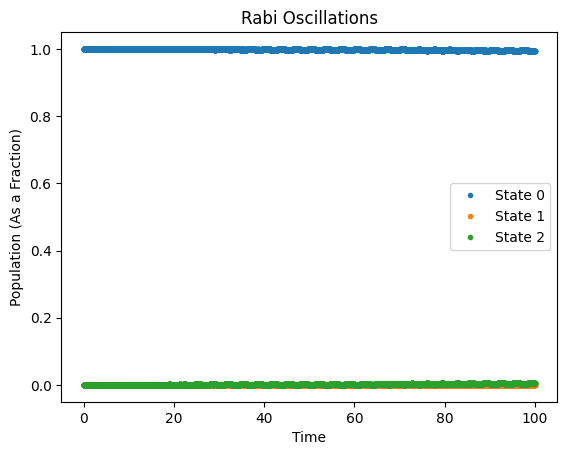

1.8735647
3.7294683


In [45]:
# Rabi Oscillations plot

number_of_states = 3

populations = [[] for _ in range(number_of_states)]
for i in range(len(output)):
    psi = output[i]
    psi /= jnp.linalg.norm(psi)

    for j in range(number_of_states):
        p_j = jnp.abs(jnp.vdot(eigenvectors[:,j], psi))**2
        populations[j].append(p_j)

for j in range(number_of_states):
    plt.plot(t_grid,populations[j],".",label=f"State {j}")
plt.ylabel("Population (As a Fraction)")
plt.xlabel("Time")
plt.title("Rabi Oscillations")
plt.legend()
plt.show()
print(eigenvalues[1]-eigenvalues[0])
print(eigenvalues[2]-eigenvalues[0])

In [12]:
import jax.numpy as jnp
import jax
from diffrax import diffeqsolve, ODETerm, Dopri5, PIDController, SaveAt
def vector_field(t, c, args):
  H_matrix = jnp.asarray(H(t), dtype=c.dtype)   # H(t) must return (n,n)
  return -1j * (H_matrix @ c)                   # returns shape (n,)
c_initial_complex = jnp.asarray(coeffs, dtype=jnp.complex64)  # or complex128 if x64 enabled
# Optional shape check (args=None, not H)
jax.eval_shape(vector_field, 0.0, c_initial_complex, None)
term = ODETerm(vector_field)
solver = Dopri5()
stepsize_controller = PIDController(rtol=1e-8, atol=1e-8)
solution = diffeqsolve(
  term,
  solver,
  t0=0.0,
  t1=10.0,
  dt0=1e-3,
  y0=c_initial_complex,   # IMPORTANT
  args=None,
  stepsize_controller=stepsize_controller,
  saveat=SaveAt(steps=True),
  throw=False,
  max_steps=200_000,
)

/Users/vincentcai/Desktop/cqednumerics/jax-gpu/lib/python3.9/site-packages/equinox/_jit.py:55: UserWarning: Complex dtype support in Diffrax is a work in progress and may not yet produce correct results. Consider splitting your computation into real and imaginary parts instead.
  out = fun(*args, **kwargs)


In [67]:
print("result:", solution.result)
print("stats:", solution.stats)
print("num saved:", solution.ys.shape[0])   # coefficients at each accepted step
C_t = solution.ys   # shape: (len(ts_req), n_coeffs)
T_t = solution.ts
valid = jnp.all(jnp.isfinite(C_t), axis=1)
T_valid = T_t[valid]
C_valid = C_t[valid]
print("num valid saved times:", int(valid.sum()))

result: diffrax._solution.RESULTS<The maximum number of solver steps was reached. Try increasing `max_steps`.>
stats: {'max_steps': 4096, 'num_accepted_steps': Array(4036, dtype=int32, weak_type=True), 'num_rejected_steps': Array(60, dtype=int32, weak_type=True), 'num_steps': Array(4096, dtype=int32, weak_type=True)}
num valid saved times: 1


In [ ]:
{'nabla_dot_nabla': Array([[-0.06611797,  0.00455319],
        [ 0.00455319, -0.06633193]], dtype=float32),
 'nabla_dot_A': Array([[ 2.9909950e-09,  1.7592566e-11],
        [ 1.7592622e-11, -3.5402588e-09]], dtype=float32),
 'A_dot_nabla': Array([[-2.9909959e-09, -4.4614570e-09],
        [ 4.4262727e-09,  3.5402619e-09]], dtype=float32),
 'A_dot_A': Array([[2.3515777e-12, 1.2073485e-12],
        [1.2073485e-12, 2.3462859e-12]], dtype=float32)}

# Widget Visualization

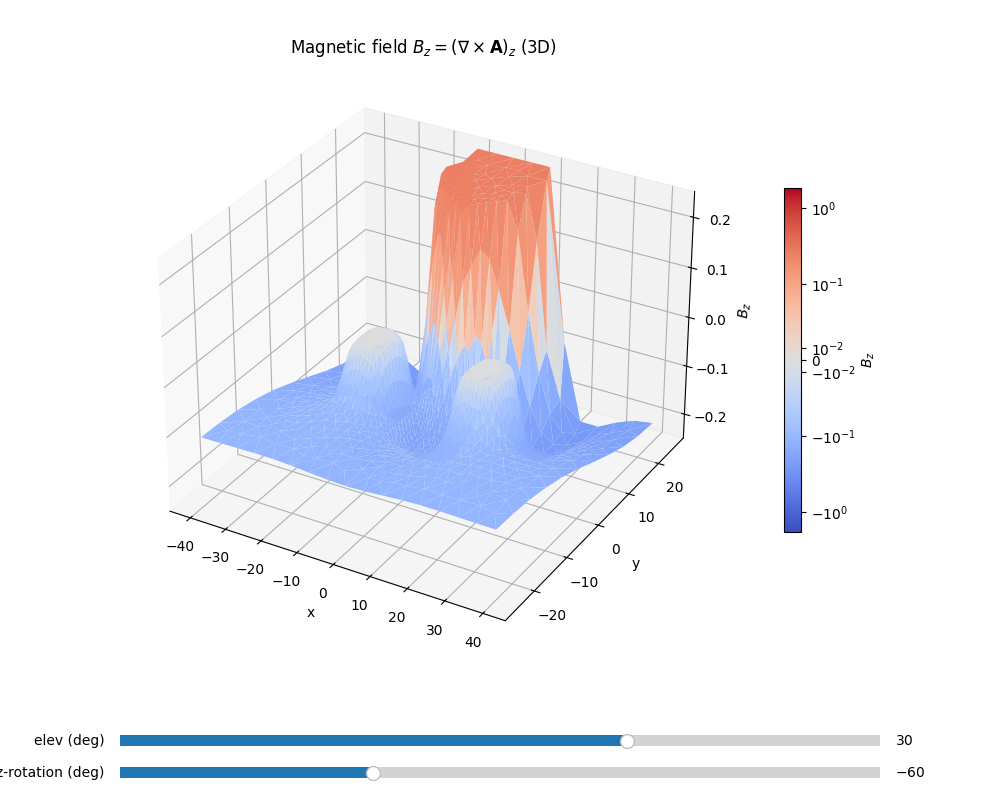

(<Figure size 1000x800 with 4 Axes>,
 <Axes3D: title={'center': 'Magnetic field $B_z = (\\nabla \\times \\mathbf{A})_z$ (3D)'}, xlabel='x', ylabel='y', zlabel='$B_z$'>)

In [158]:
vis.visualize_bz_surface(A_sol, bz_symmetric_percentile=99.0)

In [ ]:
# Now compute 

# Initial Test Below

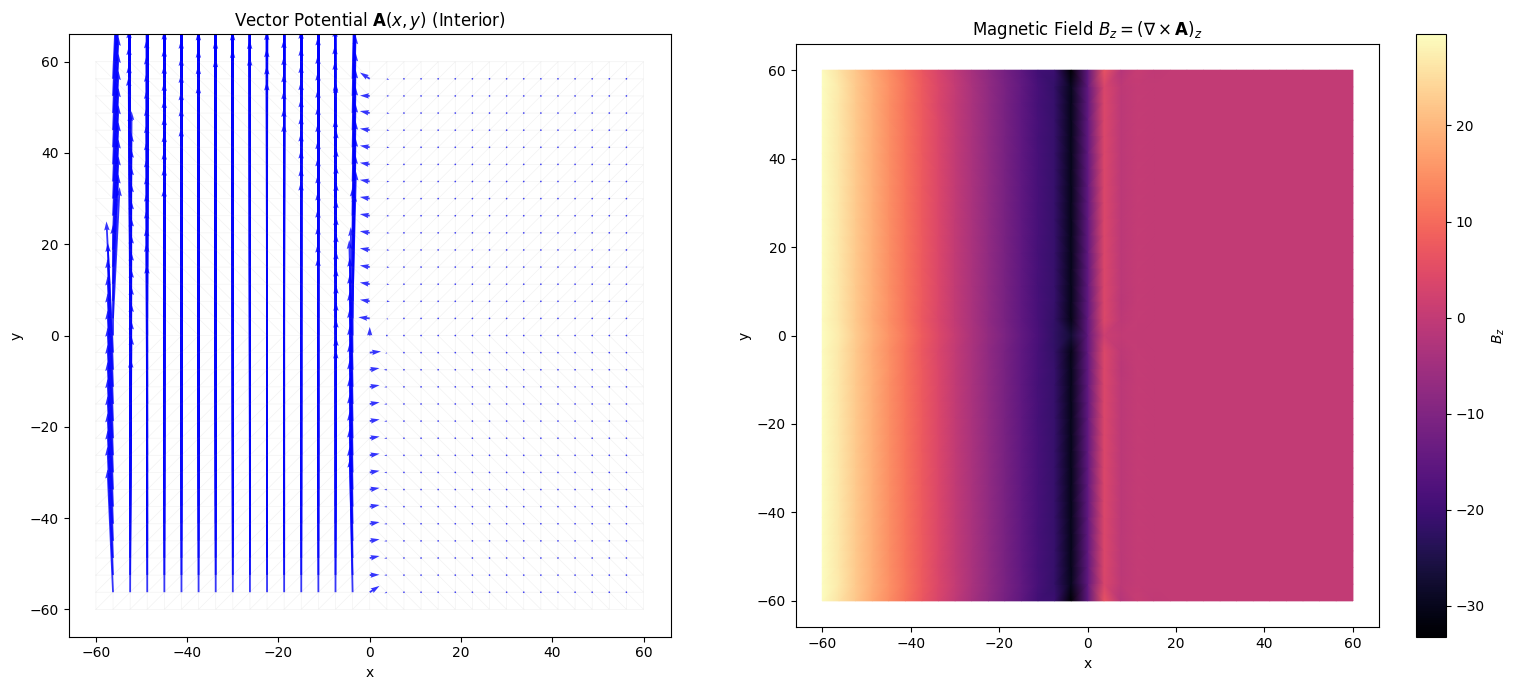

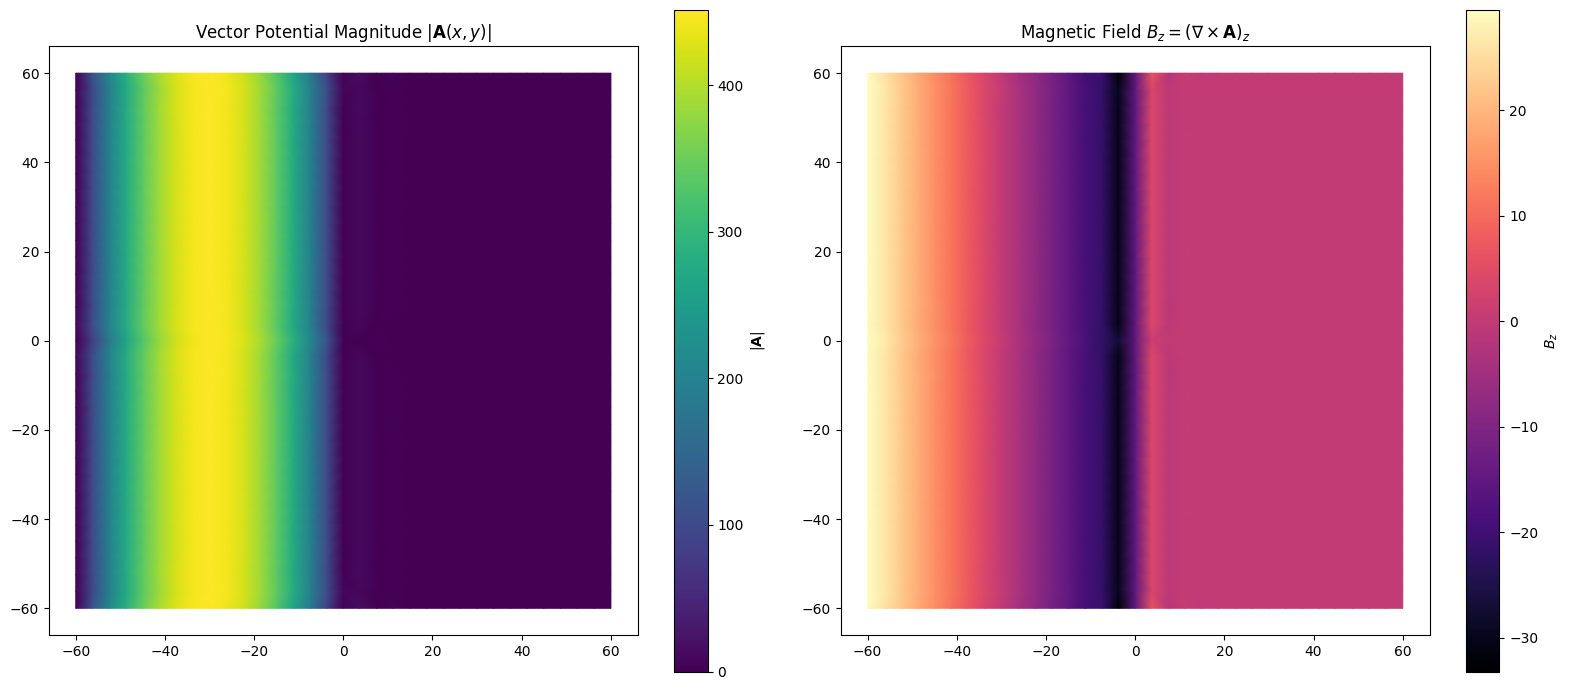

(<Figure size 1600x700 with 4 Axes>,
 array([<Axes: title={'center': 'Vector Potential Magnitude $|\\mathbf{A}(x,y)|$'}>,
        <Axes: title={'center': 'Magnetic Field $B_z = (\\nabla \\times \\mathbf{A})_z$'}>],
       dtype=object))

In [ ]:
from scipy.sparse.linalg import spsolve
from skfem import MeshTri, ElementTriN1, ElementTriP1, Basis, BilinearForm, LinearForm, asm, condense
from skfem.helpers import curl, dot

nodal_element = ElementTriP1()
nedelic_element = ElementTriN1()
basis_nodal = Basis(mesh, nodal_element, intorder=femsystem.intorder)
basis_edge = Basis(mesh, nedelic_element, intorder=femsystem.intorder)

# Simply add in filler a and b (length basis_nodal.N — P1 vertices, not len(mesh.p) on MeshTri2)
nodes_x = basis_nodal.doflocs[0]
epsilon = 1e-8
a_nodal_values = np.where(nodes_x > 0.5, 100.0, epsilon)

b_nodal_values = np.zeros((2, basis_nodal.N))
b_nodal_values[1, :] = 1.0 * (nodes_x < 0.2)  # strip source

@BilinearForm
def bilinear_form(u,v,w):
    # w['a_field'] is a scalar interpolated to the quadratures
    return curl(u) * curl(v) + w['a_field'] * dot(u, v)

@LinearForm
def general_source(v, w):
    # w['b_field'] picks off column of two elements, both scalars interpolated to the quadatures
    b_vec = np.array([w['bx'], w['by']])
    
    # dot() takes the inner product of the source vector and the test function vector 'v'
    return dot(b_vec, v)

A_matrix = asm(bilinear_form, basis_edge, 
               a_field=basis_nodal.interpolate(a_nodal_values))

b_vector = asm(general_source, basis_edge, 
               bx=basis_nodal.interpolate(b_nodal_values[0,:]),
               by=basis_nodal.interpolate(b_nodal_values[1,:]))

# SOLVE
# Enforce tangential A = 0 on boundaries
A_sol = np.zeros(basis_edge.N) # simply a vector of zeros, length of DOFs (nedelic elements)
D = basis_edge.get_dofs().all() # get the boundary indices
A_int, b_int, x_int, I = condense(A_matrix, b_vector, D=D) # condense matrices, I is indices of the interior DOFs
A_sol[I] = spsolve(A_int, b_int) # solve and put into interior only


# VISUALIZE
vis = VisualizeVF(mesh,basis_edge,A_sol)
fig, ax = vis.visualize_vf(A_sol)
vis.visualize_vf_mag(A_sol)

# Calculations for charge density

### Diamagnetic matrix $\epsilon_{ij}^{A^2}$ (minimal coupling)

From $(\cdots - q{A})^2$, the **pure $|A|^2$** piece is $(q^2/2m)|A|^2$. With ${A}$ from the Nédélec solve and modes on `femsystem`:

$$\epsilon_{ij}^{A^2} = \frac{q^2}{2m} \int \phi_i^*\, |A|^2\, \phi_j \,\mathrm{d}x$$

The code below returns a $2\times 2$ matrix $[\langle L|\cdot|L\rangle, \langle L|\cdot|R\rangle; \langle R|\cdot|L\rangle, \langle R|\cdot|R\rangle]$.

In [ ]:
# (q^2/2m) ∫ φ_i* |A|^2 φ_j dx  for i,j ∈ {left, right}; A = Nédélec A_sol, modes = femsystem scalar DOFs
from epsilon_A2_coupling import epsilon_diamagnetic_left_right_2x2

eps_A2 = epsilon_diamagnetic_left_right_2x2(
    femsystem,
    basis_edge,
    A_sol,
    u_left,
    u_right,
    q=1.0,
    m=1.0,
)
print("ε^A2 [[LL, LR], [RL, RR]]:")
print(np.asarray(eps_A2))

In [ ]:
# ∫ φ_i* [expanded (∇ − A)²] φ_j — four 2×2 blocks; A = Nédélec A_sol (see minimal_coupling_four_terms.py)
from minimal_coupling_four_terms import grad_minus_A_squared_four_terms_2x2

terms = grad_minus_A_squared_four_terms_2x2(femsystem, basis_edge, A_sol, u_left, u_right)
for name, mat in terms.items():
    print(name, ":")
    print(np.asarray(mat))

In [5]:
# Returns array where at index i, it is the true charge imbalance of the coefficient at the ith index
# Remember, length of the coeffs array is n, so will represent a maximum charge imbalance of n-1.
# convention for charge imbalance is defined by Right - Left i think??
def true_charge_imbalances(n):
    if n % 2 == 1:  # odd
        center = n // 2
        return [2 * (center - i) for i in range(n)]
    else:  # even
        center_right = n // 2
        return [2 * (center_right - i) - 1 for i in range(n)]

charge_imbalance_labels = true_charge_imbalances(len(coeffs))

# For finite N, what I want labels that tell me how much is on left, how much is on right
# N is total number of particles, n is total domain of 
half_charge_imbalance = (n-1)/2 - jnp.arange(n) # from (n-1)/2 to -(n-1)/2
num_left = N/2 + half_charge_imbalance
num_right = N/2 - half_charge_imbalance

# Normalize coeffs:
coeffs = coeffs / jnp.sqrt(jnp.sum(jnp.abs(coeffs)**2))
print(jnp.sum(jnp.abs(coeffs)**2))

exp_val_left = jnp.sum(num_left * coeffs**2)
exp_val_right = jnp.sum(num_right * coeffs**2)

# For a symmetric set of coefficients, this should be exactly N/2 for both
print(exp_val_left,exp_val_right,N/2)

0.99999994
35.0 35.0 35.0


In [69]:
# --- Diagnostic: why H(0) differs from charge-qubit form ---
import numpy as np

H0 = np.asarray(H(0.0), dtype=np.complex128)

# Charge basis operators used by the effective model
x = (n - 1) / 2 - np.arange(n)
Jz = np.diag(x)
Jz2 = np.diag(x**2)
I = np.eye(n)

def off_diag_np(n, k):
    M = np.zeros((n, n), dtype=np.complex128)
    for i in range(n - k):
        M[i, i + k] = 1.0
        M[i + k, i] = 1.0
    return M

cos_phi = 0.5 * off_diag_np(n, 1)      # nearest-neighbor (Delta m = +/-1)
pair_hop = 0.5 * off_diag_np(n, 2)     # next-nearest (Delta m = +/-2)

# Fit H0 ~ a I + b Jz + c Jz2 + d cos_phi + e pair_hop
A = np.column_stack([
    I.reshape(-1),
    Jz.reshape(-1),
    Jz2.reshape(-1),
    cos_phi.reshape(-1),
    pair_hop.reshape(-1),
])
y = H0.reshape(-1)
coef, *_ = np.linalg.lstsq(A, y, rcond=None)
a, b, c, d, e = coef
H_fit = (a * I + b * Jz + c * Jz2 + d * cos_phi + e * pair_hop)
res_rel = np.linalg.norm(H0 - H_fit, 'fro') / max(np.linalg.norm(H0, 'fro'), 1e-30)

# Coupling-strength by band (|i-j| = k)
band_norm = {}
for k in range(0, min(6, n)):
    mask = np.zeros_like(H0, dtype=bool)
    for i in range(n):
        j1 = i + k
        j2 = i - k
        if j1 < n:
            mask[i, j1] = True
        if j2 >= 0:
            mask[i, j2] = True
    band_norm[k] = np.linalg.norm(H0[mask])

print('=== Effective-basis fit of H(0) ===')
print(f'a (identity)   = {a}')
print(f'b (Jz)         = {b}')
print(f'c (Jz^2)        = {c}')
print(f'd (cos_phi)     = {d}')
print(f'e (pair_hop)    = {e}')
print(f'relative residual ||H0-H_fit||/||H0|| = {res_rel:.3e}')
print('\n=== Band norms of H(0) by |i-j| ===')
for k in sorted(band_norm):
    print(f'|i-j|={k}: {band_norm[k]:.6e}')

# If pair_hop or higher bands are sizable, H0 is NOT a pure charge-qubit Hamiltonian.


=== Effective-basis fit of H(0) ===
a (identity)   = (4221.28386742225+0j)
b (Jz)         = (0.21717364289465024+0j)
c (Jz^2)        = (4.163719002099039+0j)
d (cos_phi)     = (-7.216449660063518e-16+0j)
e (pair_hop)    = (-81.91923491160078+0j)
relative residual ||H0-H_fit||/||H0|| = 2.348e-01

=== Band norms of H(0) by |i-j| ===
|i-j|=0: 3.645955e+04
|i-j|=1: 0.000000e+00
|i-j|=2: 4.020128e+02
|i-j|=3: 0.000000e+00
|i-j|=4: 8.520682e+03
|i-j|=5: 0.000000e+00


/var/folders/3g/_3rm6vns4x97gc_975bhn77c0000gn/T/ipykernel_77448/2064701035.py:33: UserWarning: Explicitly requested dtype <class 'jax.numpy.complex128'> requested in zeros is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  mat = jnp.zeros((n, n), dtype=jnp.complex128)


In [ ]:
# --- Robust correction-only Hamiltonian (override) ---
# Run this cell after your existing definitions.
import numpy as np
import jax
import jax.numpy as jnp

# Prefer x64 to reduce complex roundoff asymmetry.
try:
    jax.config.update("jax_enable_x64", True)
except Exception:
    pass


def get_corrections_fixed(femsystem, basis_edge, A_sol, u1, u2, omega_d):
    # Keep only A-driven harmonics; no static baseline term here.
    laplacian_term, first_cross_term, second_cross_term, a2_term = epsilon_four_terms(
        femsystem, basis_edge, A_sol, u1, u2
    )
    del laplacian_term

    def correction_func(t):
        s = jnp.sin(omega_d * t)
        return first_cross_term * s + second_cross_term * s + a2_term * jnp.sin(2 * omega_d * t)

    return correction_func


def H_discrete_fixed(h_m, femsystem, basis_edge, A_sol, u_left, u_right, omega_d):
    left_raising = left_raising_operator(n, N)
    left_lowering = left_lowering_operator(n, N)
    right_raising = right_raising_operator(n, N)
    right_lowering = right_lowering_operator(n, N)

    raisings = [left_raising, right_raising]
    lowerings = [left_lowering, right_lowering]
    modes = [u_left, u_right]

    corr_funcs = [[get_corrections_fixed(femsystem, basis_edge, A_sol, modes[i], modes[j], omega_d)
                   for j in range(2)] for i in range(2)]
    bl_mats = [[raisings[i] @ lowerings[j] for j in range(2)] for i in range(2)]

    h0 = jnp.asarray(h_m, dtype=jnp.complex128)

    def res(t):
        mat = h0
        for i in range(2):
            for j in range(2):
                mat = mat + corr_funcs[i][j](t) * bl_mats[i][j]

        # Enforce Hermiticity numerically at every t.
        mat = 0.5 * (mat + jnp.conj(mat.T))
        return mat

    return res


# Build corrected Hamiltonian callable
H = H_discrete_fixed(h_m, femsystem, basis_edge, A_sol, u_left, u_right, omega_d)

# Optional stronger Hermiticity diagnostic (absolute + relative)
def check_H_hermiticity(H, t_grid, abs_tol=1e-8, rel_tol=1e-8):
    abs_errs, rel_errs = [], []
    for t in t_grid:
        Ht = np.asarray(H(t), dtype=np.complex128)
        anti = Ht - Ht.conj().T
        a = np.linalg.norm(anti, ord='fro')
        r = a / max(np.linalg.norm(Ht, ord='fro'), 1e-30)
        abs_errs.append(a)
        rel_errs.append(r)
    abs_errs = np.array(abs_errs)
    rel_errs = np.array(rel_errs)
    print(f"max abs hermiticity err = {abs_errs.max():.3e}")
    print(f"max rel hermiticity err = {rel_errs.max():.3e}")
    print(f"all(abs<{abs_tol})? {np.all(abs_errs < abs_tol)}")
    print(f"all(rel<{rel_tol})? {np.all(rel_errs < rel_tol)}")

